In [ ]:
# ============================================================
# RUN IN GOOGLE COLAB
# VM DOES NOT HAVE COMPUTE RESOURCES TO RUN LOCALLY
# ============================================================

# ============================================================
# Install
# ============================================================

!pip install --user huggingface_hub requests python-dotenv pandas numpy
!pip install snowflake-connector-python
!pip install "snowflake-connector-python[pandas]"
!pip install kaggle
!pip install qdrant-client sentence-transformers
!pip install transformers accelerate pillow
!pip install qwen-vl-utils

print("All dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.7/81.7 kB 9.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 141.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 147.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.9 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Fo

In [ ]:
from google.colab import files

# For kaggle.json file upload
files.upload()

import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.rename("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle API key configured")

Saving kaggle.json to kaggle.json
Kaggle API key configured


In [ ]:
!kaggle datasets download -d tysonpo/bike-ads-images-prices-specifications --unzip -p /content/bikes
!kaggle datasets download -d sudhanshu2198/ripik-hackfest --unzip -p /content/cars
!kaggle datasets download -d sapnilpatel/tanishq-jewellery-dataset --unzip -p /content/jewelry_new

print("All datasets downloaded")

Dataset URL: https://www.kaggle.com/datasets/tysonpo/bike-ads-images-prices-specifications
License(s): CC0-1.0
100% 196M/196M [00:12<00:00, 16.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/sudhanshu2198/ripik-hackfest
License(s): apache-2.0
100% 1.49G/1.49G [01:47<00:00, 14.8MB/s]

Dataset URL: https://www.kaggle.com/datasets/sapnilpatel/tanishq-jewellery-dataset
License(s): MIT
100% 2.11M/2.11M [00:01<00:00, 1.41MB/s]

All datasets downloaded


In [ ]:
import os

for folder in ['/content/bikes', '/content/cars', '/content/jewelry_new']:
    print(f"\n{folder}:")
    for f in os.listdir(folder):
        print(f"   {f}")


/content/bikes:
   data_ebay.json
   images
   combined_price-only.csv
   data_bike_exchange.json

/content/cars:
   train
   test

/content/jewelry_new:
   Jewellery_Data


In [ ]:
import os

# Jewelry - look inside Jewellery_Data
print("=== JEWELRY ===")
jew_contents = os.listdir('/content/jewelry_new/Jewellery_Data')
print(jew_contents[:10])

first_jew = jew_contents[0]
if os.path.isdir(f'/content/jewelry_new/Jewellery_Data/{first_jew}'):
    print(f"\nInside Jewellery_Data/{first_jew}:")
    print(os.listdir(f'/content/jewelry_new/Jewellery_Data/{first_jew}')[:5])

# Bikes - look inside images folder
print("\n=== BIKES ===")
print(os.listdir('/content/bikes/images')[:10])

# Cars - look inside train
print("\n=== CARS ===")
print(os.listdir('/content/cars/train')[:5])

=== JEWELRY ===
['ring', 'necklace']

Inside Jewellery_Data/ring:
['ring_133.jpg', 'ring_096.jpg', 'ring_172.jpg', 'ring_042.jpg', 'ring_063.jpg']

=== BIKES ===
['2414.jpg', '1748.jpg', '5491.jpg', '1378.jpg', '100945480.jpg', '7117.jpg', '5510.jpg', '2323.jpg', '6614.jpg', '173737773.jpg']

=== CARS ===
['train']


In [ ]:
import os
import uuid
import json
import pandas as pd
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas
from google.colab import userdata

# ── Helper: derive value tier ─────────────────────────────────────────────────
def get_value_tier(price_str):
    if price_str is None:
        return "unknown"
    try:
        cleaned = str(price_str).replace('$', '').replace(',', '').strip()
        price = float(cleaned)
        if price >= 5000:
            return "high"
        elif price >= 500:
            return "medium"
        else:
            return "low"
    except:
        return "unknown"

In [ ]:
# ── 1. JEWELRY ────────────────────────────────────────────────────────────────
jewelry_base = '/content/jewelry_new/Jewellery_Data'
jewelry_records = []

for category in ['necklace', 'ring']:
    folder = f'{jewelry_base}/{category}'
    if not os.path.isdir(folder):
        continue
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            jewelry_records.append({
                "record_id":            str(uuid.uuid4()),
                "image_id":             filename,
                "image_path":           f'{folder}/{filename}',
                "object_type":          "jewelry",
                "object_name":          category,
                "condition":            "new",
                "estimated_value_tier": "high",
                "location_context":     "home interior",
                "source_dataset":       "tanishq_jewellery",
                "source_flag":          "GROUND_TRUTH"
            })

jewel_clean = pd.DataFrame(jewelry_records)
print(f"Jewelry: {len(jewel_clean)} records")
print(jewel_clean['object_name'].value_counts())

Jewelry: 490 records
object_name
necklace    301
ring        189
Name: count, dtype: int64


In [ ]:
# ── 2. BIKES ──────────────────────────────────────────────────────────────────
bikes_image_folder = '/content/bikes/images'
bikes_records_raw  = []

with open('/content/bikes/data_bike_exchange.json') as f:
    for line in f:
        line = line.strip()
        if line:
            try:
                bikes_records_raw.append(json.loads(line))
            except:
                pass

# Build a lookup from ID to bike record
bike_lookup = {}
for b in bikes_records_raw:
    bid = str(b.get('ID', ''))
    if bid:
        bike_lookup[bid] = b

bike_records = []
for filename in os.listdir(bikes_image_folder):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    # Try to match image filename to a bike record by ID
    file_id = os.path.splitext(filename)[0]
    meta    = bike_lookup.get(file_id, {})

    condition = str(meta.get('Item condition', 'unknown')).lower()
    if 'new' in condition:
        cond = 'new'
    elif 'used' in condition:
        cond = 'used'
    else:
        cond = 'unknown'

    bike_records.append({
        "record_id":            str(uuid.uuid4()),
        "image_id":             filename,
        "image_path":           f'{bikes_image_folder}/{filename}',
        "object_type":          "bicycle",
        "object_name":          str(meta.get('Title', 'bicycle'))[:100],
        "condition":            cond,
        "estimated_value_tier": get_value_tier(meta.get('Price now')),
        "location_context":     "outdoor",
        "source_dataset":       "bike_exchange",
        "source_flag":          "GROUND_TRUTH"
    })

bikes_clean = pd.DataFrame(bike_records)
print(f"Bikes: {len(bikes_clean)} records")
print(bikes_clean['condition'].value_counts())

Bikes: 10052 records
condition
unknown    8070
new        1927
used         55
Name: count, dtype: int64


In [ ]:
# ── 3. CARS ───────────────────────────────────────────────────────────────────
car_label_map = {
    1: "no damage",
    2: "minor damage",
    3: "moderate damage",
    4: "severe damage"
}

car_condition_map = {
    1: "excellent",
    2: "good",
    3: "fair",
    4: "poor"
}

cars_df          = pd.read_csv('/content/cars/train/train/train.csv')
cars_image_folder = '/content/cars/train/train/images'

car_records = []
for _, row in cars_df.iterrows():
    label_num = int(row.get('label', 1))
    filename  = str(row.get('filename', ''))

    car_records.append({
        "record_id":            str(uuid.uuid4()),
        "image_id":             filename,
        "image_path":           f'{cars_image_folder}/{filename}',
        "object_type":          "vehicle",
        "object_name":          car_label_map.get(label_num, 'vehicle'),
        "condition":            car_condition_map.get(label_num, 'unknown'),
        "estimated_value_tier": "medium",
        "location_context":     "outdoor",
        "source_dataset":       "ripik_cars",
        "source_flag":          "GROUND_TRUTH"
    })

cars_clean = pd.DataFrame(car_records)
print(f"Cars: {len(cars_clean)} records")
print(cars_clean['condition'].value_counts())

Cars: 7200 records
condition
good         2349
poor         2079
unknown      2067
fair          534
excellent     171
Name: count, dtype: int64


In [ ]:
# ── 4. JOIN ALL ───────────────────────────────────────────────────────────────
ground_truth = pd.concat(
    [jewel_clean, bikes_clean, cars_clean],
    ignore_index=True
)

ground_truth = ground_truth[[
    'record_id', 'image_id', 'image_path', 'object_type', 'object_name',
    'condition', 'estimated_value_tier', 'location_context',
    'source_dataset', 'source_flag'
]]

print(f"\nTotal ground truth records: {len(ground_truth)}")
print(f"\nBreakdown by source:")
print(ground_truth['source_dataset'].value_counts())
print(f"\nBreakdown by object type:")
print(ground_truth['object_type'].value_counts())


Total ground truth records: 17742

Breakdown by source:
source_dataset
bike_exchange        10052
ripik_cars            7200
tanishq_jewellery      490
Name: count, dtype: int64

Breakdown by object type:
object_type
bicycle    10052
vehicle     7200
jewelry      490
Name: count, dtype: int64


In [ ]:
# ── 5. LOAD INTO SNOWFLAKE ────────────────────────────────────────────────────
conn = snowflake.connector.connect(
    account=userdata.get('SNOWFLAKE_ACCOUNT'),
    user=userdata.get('SNOWFLAKE_USER'),
    password=userdata.get('SNOWFLAKE_PASSWORD'),
    warehouse=userdata.get('SNOWFLAKE_WAREHOUSE'),
    database=userdata.get('SNOWFLAKE_DATABASE'),
    schema=userdata.get('SNOWFLAKE_SCHEMA'),
    role=userdata.get('SNOWFLAKE_ROLE')
)

cursor = conn.cursor()

# Create table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS GROUND_TRUTH (
        record_id               VARCHAR,
        image_id                VARCHAR,
        image_path              VARCHAR,
        object_type             VARCHAR,
        object_name             VARCHAR,
        condition               VARCHAR,
        estimated_value_tier    VARCHAR,
        location_context        VARCHAR,
        source_dataset          VARCHAR,
        source_flag             VARCHAR DEFAULT 'GROUND_TRUTH',
        created_at              TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
""")
print("Table ready")

# Truncate if already has data
cursor.execute("SELECT COUNT(*) FROM GROUND_TRUTH")
count = cursor.fetchone()[0]
if count > 0:
    print(f"  Table has {count} existing records — truncating")
    cursor.execute("TRUNCATE TABLE GROUND_TRUTH")

# Uppercase columns for Snowflake
ground_truth.columns = [col.upper() for col in ground_truth.columns]

# Bulk insert
success, nchunks, nrows, _ = write_pandas(
    conn=conn,
    df=ground_truth,
    table_name='GROUND_TRUTH',
    auto_create_table=False
)

print(f"{nrows} records inserted into Snowflake")

# Restore lowercase columns for rest of the Jupyter Notebook
ground_truth.columns = [col.lower() for col in ground_truth.columns]

# Verify
cursor.execute("SELECT COUNT(*) FROM GROUND_TRUTH")
print(f"Final count in Snowflake: {cursor.fetchone()[0]}")

cursor.close()
conn.close()

Table ready
17742 records inserted into Snowflake
Final count in Snowflake: 17742


In [ ]:
# ============================================================
# Load Qwen2-VL-7B-Instruct
# ============================================================

import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

MODEL_ID  = "Qwen/Qwen2-VL-7B-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model     = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto",
)
model.eval()
print(f"{MODEL_ID} loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

Qwen/Qwen2-VL-7B-Instruct loaded


In [ ]:
# ============================================================
# Qdrant: Index Ground Truth Records
# ============================================================

from qdrant_client import QdrantClient
from qdrant_client.models import (
    VectorParams, Distance, PointStruct,
    Filter, FieldCondition, MatchValue, PayloadSchemaType
)
from sentence_transformers import SentenceTransformer

QDRANT_URL        = userdata.get('QDRANT_URL')
QDRANT_API_KEY    = userdata.get('QDRANT_API_KEY')
QDRANT_COLLECTION = "object_labels"

qdrant        = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
embed_model   = SentenceTransformer("all-MiniLM-L6-v2")

# Create collection if needed
if not qdrant.collection_exists(QDRANT_COLLECTION):
    qdrant.create_collection(
        collection_name=QDRANT_COLLECTION,
        vectors_config=VectorParams(size=384, distance=Distance.COSINE),
    )
    qdrant.create_payload_index(
        collection_name=QDRANT_COLLECTION,
        field_name="object_type",
        field_schema=PayloadSchemaType.KEYWORD,
    )
    print(f"Collection '{QDRANT_COLLECTION}' created")
else:
    print(f"ℹCollection '{QDRANT_COLLECTION}' already exists")

# Embed and upsert ground truth records
def record_to_text(row: dict) -> str:
    return (
        f"{row['object_type']} | {row['object_name']} | "
        f"condition: {row['condition']} | "
        f"value: {row['estimated_value_tier']} | "
        f"location: {row['location_context']}"
    )

# Use lowercase copy for embedding
gt_lower = ground_truth.copy()
gt_lower.columns = [c.lower() for c in gt_lower.columns]

BATCH_SIZE    = 100
rows          = gt_lower.to_dict(orient="records")
total_upserted = 0

for i in range(0, len(rows), BATCH_SIZE):
    batch   = rows[i : i + BATCH_SIZE]
    texts   = [record_to_text(r) for r in batch]
    vectors = embed_model.encode(texts, show_progress_bar=False).tolist()

    points = [
        PointStruct(
            id      = str(uuid.uuid4()),
            vector  = vectors[j],
            payload = {
                "record_id":            batch[j]["record_id"],
                "image_id":             batch[j]["image_id"],
                "object_type":          batch[j]["object_type"],
                "object_name":          batch[j]["object_name"],
                "condition":            batch[j]["condition"],
                "estimated_value_tier": batch[j]["estimated_value_tier"],
                "location_context":     batch[j]["location_context"],
                "source_dataset":       batch[j]["source_dataset"],
            }
        )
        for j in range(len(batch))
    ]
    qdrant.upsert(collection_name=QDRANT_COLLECTION, points=points)
    total_upserted += len(points)
    print(f"  Upserted {total_upserted}/{len(rows)}", end="\r")

print(f"\n{total_upserted} records indexed into Qdrant")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

ℹ️  Collection 'object_labels' already exists
  Upserted 17742/17742
✅ 17742 records indexed into Qdrant


In [ ]:
# ============================================================
# RAG Retrieval Function
# ============================================================

def retrieve_context(query: str, object_type: str = None, top_k: int = 3) -> str:
    """
    Embed query → search Qdrant → return formatted context string
    for injection into the Qwen2-VL prompt.
    """
    query_vector  = embed_model.encode(query).tolist()

    search_filter = None
    if object_type:
        search_filter = Filter(must=[
            FieldCondition(key="object_type", match=MatchValue(value=object_type))
        ])

    results = qdrant.query_points(
        collection_name=QDRANT_COLLECTION,
        query=query_vector,
        limit=top_k,
        query_filter=search_filter,
    )

    if not results.points:
        return ""

    lines = []
    for i, hit in enumerate(results.points, 1):
        p = hit.payload
        lines.append(
            f"Example {i}: object_type={p['object_type']}, "
            f"object_name={p['object_name']}, condition={p['condition']}, "
            f"value_tier={p['estimated_value_tier']}, "
            f"location={p['location_context']}"
        )
    return "\n".join(lines)

In [ ]:
# ============================================================
# Prompt Builder
# ============================================================

# Per-type label schemas so the model knows exactly what fields matter
TYPE_SCHEMAS = {
    "vehicle": {
        "damage_type":  "describe damage or 'none'",
        "severity":     "minor | moderate | severe | none",
        "vehicle_part": "damaged part e.g. 'front bumper', or 'none'",
    },
    "bicycle": {
        "bike_type":       "road | mountain | hybrid | BMX | e-bike | other",
        "frame_material":  "carbon | alloy | steel | titanium | unknown",
        "damage_type":     "describe damage or 'none'",
    },
    "jewelry": {
        "jewelry_type": "ring | necklace | bracelet | earring | other",
        "material":     "gold | silver | platinum | mixed | unknown",
        "gemstone":     "diamond | ruby | sapphire | emerald | none | unknown",
    },
}

SYSTEM_PROMPT = (
    "You are a synthetic data generation assistant that analyzes product images.\n"
    "You output ONLY valid JSON. No explanation, no markdown, no code fences.\n"
    "Your response must be parseable by json.loads() directly."
)

def build_prompt(image, object_type: str, retrieved_context: str) -> list[dict]:
    """
    Build Qwen2-VL messages with RAG context and a type-specific label schema.
    Mirrors build_prompt() from the text model exactly — image replaces text input.
    """
    # Base fields every object type must produce
    base_schema = {
        "object_type":          "vehicle | bicycle | jewelry",
        "object_name":          "specific name of the object",
        "condition":            "new | like-new | good | fair | poor | unknown",
        "estimated_value_tier": "high | medium | low | unknown",
        "location_context":     "indoor/studio | outdoor | home interior | showroom | unknown",
        "confidence_score":     "float 0.0 to 1.0",
    }

    # Merge in type-specific fields
    extra = TYPE_SCHEMAS.get(object_type, {})
    full_schema = {**base_schema, **extra}
    schema_str  = json.dumps(full_schema, indent=2)

    rag_block = ""
    if retrieved_context:
        rag_block = (
            "\nRetrieved reference examples — use these to ground your output:\n"
            "---\n"
            f"{retrieved_context}\n"
            "---\n"
        )

    user_text = (
        f"Analyze this image and generate synthetic metadata labels.\n"
        f"Object type hint: {object_type}\n"
        f"{rag_block}\n"
        f"Return EXACTLY this JSON structure — nothing outside it:\n"
        f'{{\n'
        f'  "image_id": "img_001",\n'
        f'  "labels": {schema_str}\n'
        f'}}\n\n'
        f"Start your response with {{ and end with }}."
    )

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": user_text},
            ],
        },
    ]

In [ ]:
# ============================================================
# Parse & Validate  (mirrors text model logic)
# ============================================================

import re

VALID_CONDITIONS  = {"new", "like-new", "good", "fair", "poor", "unknown"}
VALID_VALUE_TIERS = {"high", "medium", "low", "unknown"}
VALID_SEVERITIES  = {"minor", "moderate", "severe", "none"}

class ParseError(Exception):      pass
class ValidationError(Exception): pass


def parse_output(raw: str) -> dict:
    """Strip fences, extract first valid JSON object — same as text model."""
    text = raw.strip()
    if text.startswith("```"):
        text = re.sub(r"^```[a-z]*\n?", "", text)
        text = re.sub(r"\n?```$", "", text.strip())

    brace_stack, start = 0, None
    for i, ch in enumerate(text):
        if ch == "{":
            if brace_stack == 0: start = i
            brace_stack += 1
        elif ch == "}":
            brace_stack -= 1
            if brace_stack == 0 and start is not None:
                try:    return json.loads(text[start:i+1])
                except: continue

    raise ParseError(f"No valid JSON found.\nRaw (first 300 chars): {raw[:300]}")


def validate_and_repair(data: dict, object_type: str) -> dict:
    """
    Repair missing/invalid fields with safe defaults.
    Mirrors validate_records() from the text model.
    """
    labels = data.get("labels", {})

    # Clamp confidence
    try:
        labels["confidence_score"] = max(0.0, min(1.0, float(labels.get("confidence_score", 0.5))))
    except:
        labels["confidence_score"] = 0.5

    # Safe defaults for base fields
    defaults = {
        "object_type":          object_type,
        "object_name":          "unknown",
        "condition":            "unknown",
        "estimated_value_tier": "unknown",
        "location_context":     "unknown",
        "confidence_score":     0.5,
    }

    # Safe defaults for type-specific fields
    type_defaults = {
        "vehicle": {"damage_type": "none", "severity": "none", "vehicle_part": "none"},
        "bicycle": {"bike_type": "unknown", "frame_material": "unknown", "damage_type": "none"},
        "jewelry": {"jewelry_type": "unknown", "material": "unknown", "gemstone": "none"},
    }
    defaults.update(type_defaults.get(object_type, {}))

    for k, v in defaults.items():
        if k not in labels or labels[k] in [None, ""]:
            labels[k] = v

    # Normalize enums
    if labels.get("condition") not in VALID_CONDITIONS:
        labels["condition"] = "unknown"
    if labels.get("estimated_value_tier") not in VALID_VALUE_TIERS:
        labels["estimated_value_tier"] = "unknown"
    if object_type == "vehicle" and labels.get("severity") not in VALID_SEVERITIES:
        labels["severity"] = "none"

    data["labels"] = labels
    return data

In [ ]:
# ============================================================
# Core Inference Function
# ============================================================

from PIL import Image as PILImage

def generate_labels_from_image(image_path: str, object_type: str, image_id: str) -> dict:
    """
    Main function — mirrors generate_synthetic_data() from the text model.

    1. Load image from local path
    2. Retrieve RAG context from Qdrant (filtered by object_type)
    3. Build prompt with RAG context injected
    4. Run Qwen2-VL
    5. Parse + validate JSON
    6. Return structured result dict
    """
    # 1. Load image
    image = PILImage.open(image_path).convert("RGB")

    # 2. RAG retrieval — filtered to same object type for relevant examples
    query             = f"{object_type} condition value damage location"
    retrieved_context = retrieve_context(query=query, object_type=object_type, top_k=3)

    # 3. Build prompt
    messages = build_prompt(image, object_type, retrieved_context)

    # 4. Run Qwen2-VL
    text_input = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text_input],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=300)

    trimmed    = generated_ids[:, inputs.input_ids.shape[1]:]
    raw_output = processor.batch_decode(
        trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    # 5. Parse + validate
    try:
        parsed    = parse_output(raw_output)
        validated = validate_and_repair(parsed, object_type)
        parse_ok  = True
    except ParseError:
        validated = {"labels": {}}
        validate_and_repair(validated, object_type)
        parse_ok  = False

    # 6. Attach lineage
    validated["image_id"]         = image_id
    validated["inference_id"]     = str(uuid.uuid4())
    validated["rag_context_used"] = retrieved_context[:500]
    validated["raw_model_output"] = raw_output[:2000]
    validated["parse_success"]    = parse_ok

    return validated


# ============================================================
# Snowflake Output Table + Save Helper
# ============================================================

def get_sf_conn():
    return snowflake.connector.connect(
        account   = userdata.get('SNOWFLAKE_ACCOUNT'),
        user      = userdata.get('SNOWFLAKE_USER'),
        password  = userdata.get('SNOWFLAKE_PASSWORD'),
        warehouse = userdata.get('SNOWFLAKE_WAREHOUSE'),
        database  = userdata.get('SNOWFLAKE_DATABASE'),
        schema    = userdata.get('SNOWFLAKE_SCHEMA'),
        role      = userdata.get('SNOWFLAKE_ROLE'),
    )

def ensure_output_table():
    conn   = get_sf_conn()
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS SYNTHETIC_LABELS (
            inference_id          VARCHAR,
            image_id              VARCHAR,
            source_dataset        VARCHAR,
            -- base labels (all types)
            object_type           VARCHAR,
            object_name           VARCHAR,
            condition             VARCHAR,
            estimated_value_tier  VARCHAR,
            location_context      VARCHAR,
            confidence_score      FLOAT,
            -- vehicle-specific
            damage_type           VARCHAR,
            severity              VARCHAR,
            vehicle_part          VARCHAR,
            -- bicycle-specific
            bike_type             VARCHAR,
            frame_material        VARCHAR,
            -- jewelry-specific
            jewelry_type          VARCHAR,
            material              VARCHAR,
            gemstone              VARCHAR,
            -- lineage
            parse_success         BOOLEAN,
            rag_context_used      VARCHAR(1000),
            raw_model_output      VARCHAR(4000),
            created_at            TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """)
    cursor.close()
    conn.close()
    print("SYNTHETIC_LABELS table ready")

ensure_output_table()

# Collect results in memory, write once at the end
results_buffer = []

def save_to_buffer(result: dict, source_dataset: str):
    labels = result.get("labels", {})
    results_buffer.append({
        "INFERENCE_ID":          result.get("inference_id"),
        "IMAGE_ID":              result.get("image_id"),
        "SOURCE_DATASET":        source_dataset,
        "OBJECT_TYPE":           labels.get("object_type"),
        "OBJECT_NAME":           labels.get("object_name"),
        "CONDITION":             labels.get("condition"),
        "ESTIMATED_VALUE_TIER":  labels.get("estimated_value_tier"),
        "LOCATION_CONTEXT":      labels.get("location_context"),
        "CONFIDENCE_SCORE":      labels.get("confidence_score"),
        "DAMAGE_TYPE":           labels.get("damage_type"),
        "SEVERITY":              labels.get("severity"),
        "VEHICLE_PART":          labels.get("vehicle_part"),
        "BIKE_TYPE":             labels.get("bike_type"),
        "FRAME_MATERIAL":        labels.get("frame_material"),
        "JEWELRY_TYPE":          labels.get("jewelry_type"),
        "MATERIAL":              labels.get("material"),
        "GEMSTONE":              labels.get("gemstone"),
        "PARSE_SUCCESS":         result.get("parse_success", False),
        "RAG_CONTEXT_USED":      result.get("rag_context_used", "")[:1000],
        "RAW_MODEL_OUTPUT":      result.get("raw_model_output", "")[:4000],
    })

def flush_buffer_to_snowflake():
    if not results_buffer:
        print("Nothing to flush")
        return
    df   = pd.DataFrame(results_buffer)
    conn = get_sf_conn()
    write_pandas(conn=conn, df=df, table_name="SYNTHETIC_LABELS", auto_create_table=False)
    conn.close()
    print(f"Flushed {len(results_buffer)} records to Snowflake")
    results_buffer.clear()

✅ SYNTHETIC_LABELS table ready


In [ ]:
# ============================================================
# Batch Pipeline: Ground Truth → VLM → Snowflake
# ============================================================

from tqdm import tqdm

def run_batch(gt_df: pd.DataFrame, max_images: int = 50, flush_every: int = 10):
    gt_lower = gt_df.copy()
    gt_lower.columns = [c.lower() for c in gt_lower.columns]

    sample  = gt_lower.sample(n=min(max_images, len(gt_lower)), random_state=42)
    success = 0
    failed  = 0

    for i, (_, row) in enumerate(tqdm(sample.iterrows(), total=len(sample), desc="Labeling images")):
        image_path = row["image_path"]

        if not image_path or pd.isna(image_path) or not os.path.exists(str(image_path)):
            print(f"  Missing: {image_path}")
            failed += 1
            continue

        try:
            result = generate_labels_from_image(
                image_path  = image_path,
                object_type = row["object_type"],
                image_id    = row["image_id"],
            )
            # Add to buffer instead of writing immediately
            save_to_buffer(result, source_dataset=row["source_dataset"])
            success += 1
            print(
                f"  {row['image_id'][:30]:30s} | "
                f"{result['labels']['object_type']:8s} | "
                f"condition={result['labels']['condition']:8s} | "
                f"conf={result['labels']['confidence_score']:.2f}"
            )
        except Exception as e:
            print(f"  {row['image_id']} — {e}")
            failed += 1

        # Flush to Snowflake every N images
        if (i + 1) % flush_every == 0:
            flush_buffer_to_snowflake()

    # Final flush
    flush_buffer_to_snowflake()
    print(f"\nBatch done: {success} succeeded, {failed} failed")


run_batch(ground_truth, max_images=50, flush_every=10)

Labeling images:   2%|▏         | 1/50 [00:09<07:23,  9.05s/it]

  ✅ 35.jpg                         | vehicle | bicycle | condition=good     | conf=0.95


Labeling images:   4%|▍         | 2/50 [00:16<06:25,  8.03s/it]

  ✅ 3213.jpg                       | vehicle  | condition=poor     | conf=0.90


Labeling images:   6%|▌         | 3/50 [00:23<05:59,  7.65s/it]

...

  ✅ 2283.jpg                       | vehicle | bicycle | condition=unknown  | conf=0.90


Labeling images:  98%|█████████▊| 49/50 [06:30<00:07,  7.37s/it]

  ✅ 4322.jpg                       | vehicle | bicycle | condition=unknown  | conf=0.90
  ✅ 346.jpg                        | vehicle  | condition=poor     | conf=0.95


Labeling images: 100%|██████████| 50/50 [06:46<00:00,  8.14s/it]

✅ Flushed 10 records to Snowflake
⚠️ Nothing to flush

✅ Batch done: 50 succeeded, 0 failed


In [ ]:
# ============================================================
# Verify Results in Snowflake
# ============================================================

conn   = get_sf_conn()
cursor = conn.cursor()

cursor.execute("""
    SELECT
        object_type,
        COUNT(*)                                          AS total,
        ROUND(AVG(confidence_score), 3)                  AS avg_confidence,
        SUM(CASE WHEN parse_success THEN 1 ELSE 0 END)   AS parsed_ok
    FROM SYNTHETIC_LABELS
    GROUP BY object_type
    ORDER BY total DESC
""")

rows = cursor.fetchall()
print(f"\n{'object_type':12s}  {'total':>6}  {'avg_conf':>10}  {'parsed_ok':>10}")
print(f"{'─'*12}  {'─'*6}  {'─'*10}  {'─'*10}")
for r in rows:
    print(f"{str(r[0]):12s}  {r[1]:>6}  {float(r[2] or 0):>10.3f}  {r[3]:>10}")

cursor.close()
conn.close()


object_type    total    avg_conf   parsed_ok
────────────  ──────  ──────────  ──────────
vehicle | bicycle     124       0.946         124
vehicle           72       0.853          72
jewelry            3       1.000           3


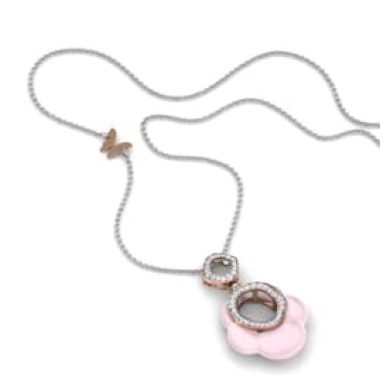

{
  "object_type": "jewelry",
  "object_name": "necklace",
  "condition": "new",
  "estimated_value_tier": "high",
  "location_context": "home interior",
  "confidence_score": 1.0,
  "jewelry_type": "necklace",
  "material": "gold",
  "gemstone": "unknown"
}


In [ ]:
# ============================================================
# Jewelry Check
# ============================================================

from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Examples
# ring_047.jpg, /content/jewelry_new/Jewellery_Data/ring/ring_047.jpg
# necklace_56.jpg, /content/jewelry_new/Jewellery_Data/necklace/necklace_56.jpg

# Pick your image by filename here
IMAGE_PATH = "/content/jewelry_new/Jewellery_Data/necklace/necklace_56.jpg"

# Show the image
img = PILImage.open(IMAGE_PATH)
plt.imshow(img)
plt.axis("off")
plt.show()

# Run the model and print output
gt_lower = ground_truth.copy()
gt_lower.columns = [c.lower() for c in gt_lower.columns]

test_row = gt_lower[gt_lower["image_path"] == IMAGE_PATH].iloc[0]

result = generate_labels_from_image(
    image_path  = IMAGE_PATH,
    object_type = test_row["object_type"],
    image_id    = test_row["image_id"],
)

print(json.dumps(result["labels"], indent=2))

In [ ]:
# ============================================================
# Random Check
# ============================================================

from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Replace the two lines below with this to choose a specific image to run the model
# test_row = ground_truth[ground_truth["image_path"].str.contains("some_filename")].iloc[0]


# Pick any row from ground truth to test
test_row = ground_truth.sample(1).iloc[0]
test_row.index = [i.lower() for i in test_row.index]

# Show the image
img = PILImage.open(test_row["image_path"])
plt.imshow(img)
plt.axis("off")
plt.show()

# Run the model and print output
result = generate_labels_from_image(
    image_path  = test_row["image_path"],
    object_type = test_row["object_type"],
    image_id    = test_row["image_id"],
)

print(json.dumps(result["labels"], indent=2))

NameError: name 'ground_truth' is not defined